# Slogan Memorability Prediction Models
Authors: Ada Aka and John McCoy

This notebook provides tools to predict **cued brand recall** and **slogan recognition** for brand slogans.

### Prediction models you can choose between:

1. Embedding-based models: Direct predictions from OpenAI embeddings
2. Proxy factors models: Predictions using psycholinguistic and semantic features proxied from embeddings

There are two kinds of proxy factors modesl. One kind that operate across 45 raw features and another kind that operates over 25 summary features. The summary features version trades a little predictive accuracy for more interpretability. The summary features version of the proxy-factors model thus provides SHAP importance values and provides a SHAP waterfall plot for the slogans being tested to see how features of the slogan are contributing towards its predicted memorability.

Brand information can be supplied in the form of a brand name, a brief description of the brand, or any other textual representation of the brand. For recognition, we provide a proxy-factors model that can be applied if users do not have brand information.

### Examples:

The notebook provides a demonstration of running each kind of model on slogans contained in example_slogans.csv.

### Understanding the predictions:

Predictions are made for both slogan recognition and cued brand recall. To help interpret the predictions, we provide some summary statistics for the training data.

#### Recognition

Recognition measures whether consumers can correctly identify a slogan as one they have previously seen, or correctly reject a slogan they have not seen. It is operationalized as the proportion of correct responses across both old (seen) and new (unseen) slogans in a recognition memory task. Values range from 0 to 1, where higher values indicate that a slogan is more easily recognized.

- Training data mean: **0.80** (most slogans are recognized well above chance)
- Training data range: approximately 0.60 to 0.97
- Interquartile range: approximately 0.73 to 0.87

#### Recall

Recall measures whether consumers can correctly recall the brand name when given only the slogan as a cue (cued brand recall). It is operationalized as the proportion of participants who correctly name the brand. Values range from 0 to 1, where higher values indicate a stronger slogan–brand association.

- Training data mean: **0.09** (most slogans have low cued recall)
- Training data range: approximately 0.00 to 0.92
- The distribution is heavily right-skewed

#### Interpretation

- Recognition and recall operate on very different scales: recognition is substantially easier than recall.
- For new slogans being considered, we suggest running the prediction models on variations of the slogans you have in mind and paying most attention to the **relative performance** of the slogans in your consideration set.

## Table of Contents

1. [Setup & Configuration](#setup)
2. [Embedding Acquisition](#embedding-acquisition)
3. [Embedding Models](#embedding-models)
   - [Recognition](#embedding-recognition)
   - [Recall](#embedding-recall)
4. [Proxy Factors Models (45 raw features)](#proxy-features-models)
   - [Recognition (45 raw features)](#proxy-recognition)
   - [Recall (45 raw features)](#proxy-recall)
   - [Recognition without brand fit (45 raw features)](#proxy-recognition-no-brand)
5. [Proxy Factors Models (25 feature summary)](#proxy-features-summary25)
   - [Recognition (25 feature summary)](#proxy-recognition-25)
   - [Recall (25 feature summary)](#proxy-recall-25)


---
## 1. Setup & Configuration <a id='setup'></a>

### Required Libraries
Install required packages:
```bash
pip install numpy pandas openai statsmodels scikit-learn
```

### API Key Setup
Obtain an OpenAI API key from: https://platform.openai.com/api-keys

**Note**: The API key is currently hardcoded for testing but should be moved to environment variables for safer production use.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import pickle
import statsmodels.api as sm
from openai import OpenAI
import os
import warnings
import shap

# Suppress performance warnings for cleaner output
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [ ]:
# API Key Configuration
# Set the OPENAI_API_KEY environment variable before running.
api_key = os.getenv("OPENAI_API_KEY", "")


---
## 2. Embedding Acquisition <a id='embedding-acquisition'></a>

This is a helper function to retrieve text embeddings from OpenAI's `text-embedding-ada-002` model.

Function: `get_embeddings()`
- **Purpose**: Convert text into numerical vectors (embeddings) for model input
- **Input**: List of text strings (slogans or brand names)
- **Output**: NumPy array of embeddings, shape (n_texts, 1536)
- **Parameters**:
  - `text_list`: List of strings to embed
  - `model`: OpenAI embedding model (default: "text-embedding-ada-002")
  - `chunk_size`: Batch size for API calls (default: 600)
  - `api_key`: OpenAI API key

In [ ]:
def get_embeddings(text_list, model="text-embedding-ada-002", chunk_size=600, api_key=None):
    """
    Get embeddings for a list of texts with chunking for efficiency.

    Parameters:
    -----------
    text_list : list of str
        List of texts to embed
    model : str
        OpenAI embedding model (default: "text-embedding-ada-002")
    chunk_size : int
        Number of texts to process per API call (default: 600)
    api_key : str, optional
        OpenAI API key (if None, uses OPENAI_API_KEY environment variable)

    Returns:
    --------
    np.ndarray : Array of embeddings, shape (n_texts, embedding_dim)
    """

    # Initialize OpenAI client
    if not api_key:
        api_key = os.getenv("OPENAI_API_KEY")
        if not api_key:
            raise ValueError("No API key provided. Set OPENAI_API_KEY environment variable or pass api_key parameter")

    client = OpenAI(api_key=api_key)

    # Filter to valid strings only
    valid_texts = [t for t in text_list if isinstance(t, str) and len(t) > 0]

    if len(valid_texts) == 0:
        raise ValueError("No valid text strings provided")

    # Get embeddings in chunks to avoid rate limits
    embeddings = []
    for i in range(0, len(valid_texts), chunk_size):
        chunk = valid_texts[i:i + chunk_size]
        response = client.embeddings.create(model=model, input=chunk)
        embeddings.extend([item.embedding for item in response.data])

    return np.array(embeddings)

---
## 3. Embedding Models <a id='embedding-models'></a>

These models make predictions directly from text embeddings without requiring any additional memorability features. They making predictions using models we have pre-trained on memorability data.

### 3a. Recognition Embedding Model <a id='embedding-recognition'></a>

Recognition measures whether consumers can correct identify a slogan as previously seen or not.

**Model**: Uses slogan embeddings only (brand information not required for recognition).

In [ ]:
def predict_recognition(
    csv_path,
    model_path,
    slogan_column='slogan',
    embedding_model="text-embedding-ada-002",
    api_key=api_key
):
    """
    Predict recognition probability for slogans using only slogan embeddings.

    Parameters:
    -----------
    csv_path : str
        Path to CSV file containing slogans
    model_path : str
        Path to saved recognition model (pickle file)
    slogan_column : str
        Name of column containing slogan text (default: 'slogan')
    embedding_model : str
        OpenAI embedding model to use (default: "text-embedding-ada-002")
    api_key : str, optional
        OpenAI API key (if None, uses OPENAI_API_KEY environment variable)

    Returns:
    --------
    pd.DataFrame : Original dataframe with added 'predicted_recognition' column
    """

    # Read CSV
    print(f"Reading CSV from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Validate column
    if slogan_column not in df.columns:
        raise ValueError(f"Column '{slogan_column}' not found in dataframe. Available columns: {df.columns.tolist()}")

    # Get embeddings for all slogans
    print(f"Computing embeddings for {len(df)} slogans...")
    embeddings = get_embeddings(df[slogan_column].tolist(), model=embedding_model, api_key=api_key)

    # Create dataframe with embedding columns
    n_dims = embeddings.shape[1]
    embedding_cols = [f"ada_embedding_no{i}" for i in range(n_dims)]
    embedding_df = pd.DataFrame(embeddings, columns=embedding_cols, index=df.index)

    # Load recognition model
    print("Loading recognition model...")
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
        model = model_data['model']

    X_pred = sm.add_constant(embedding_df[embedding_cols], has_constant="add")
    df['predicted_recognition'] = model.predict(X_pred)

    return df

#### Example Usage

In [ ]:
# Example: Predict recognition using embedding model
# Requires: a CSV with 'slogan' column, in this example the csv is "example_slogans.csv"

recognition_df = predict_recognition(
    csv_path="example_slogans.csv",
    model_path="./models/trained_model_embeddings_binomial_recognition.pkl"
)

# Save results
recognition_df.to_csv("slogans_recognition_predictions_embeddings.csv", index=False)

# Display results
recognition_df

Reading CSV from example_slogans.csv...
Computing embeddings for 2 slogans...
Loading recognition model...


,slogan,brand,predicted_recognition
0,Equipment that doesn’t care about the weather,Orvix,0.892366
1,"Strength you can hear, feel, and trust",Kavelo,0.734429


### 3b. Recall Embedding Model <a id='embedding-recall'></a>

Recall measures whether consumers can recall a brand name when given only the slogan

**Model**: Uses concatenated slogan + brand embeddings.

In [ ]:
def predict_recall(
    csv_path,
    model_path,
    slogan_column='slogan',
    brand_column='brand',
    embedding_model="text-embedding-ada-002",
    api_key=None
):
    """
    Predict recall probability for slogans using embeddings.

    Automatically detects whether the model expects slogan-only or
    slogan+brand concatenated embeddings based on model dimensions.

    Parameters:
    -----------
    csv_path : str
        Path to CSV file containing slogans and brands
    model_path : str
        Path to saved recall model (pickle file)
    slogan_column : str
        Name of column containing slogan text (default: 'slogan')
    brand_column : str
        Name of column containing brand text (default: 'brand')
    embedding_model : str
        OpenAI embedding model to use (default: "text-embedding-ada-002")
    api_key : str, optional
        OpenAI API key (if None, uses OPENAI_API_KEY environment variable)

    Returns:
    --------
    pd.DataFrame : Original dataframe with added 'predicted_recall' column
    """

    # Read CSV
    print(f"Reading CSV from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Validate columns
    if slogan_column not in df.columns:
        raise ValueError(f"Column '{slogan_column}' not found in dataframe. Available columns: {df.columns.tolist()}")
    if brand_column not in df.columns:
        raise ValueError(f"Column '{brand_column}' not found in dataframe. Available columns: {df.columns.tolist()}")

    # Get embeddings for slogans
    print(f"Computing slogan embeddings for {len(df)} rows...")
    slogan_embeddings = get_embeddings(df[slogan_column].tolist(), model=embedding_model, api_key=api_key)

    # Load recall model to check expected dimensions
    print("Loading recall model...")
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
        model = model_data['model']

    n_model_params = len(model.params)
    n_slogan_dims = slogan_embeddings.shape[1]

    # Determine if model expects slogan-only or slogan+brand embeddings
    if n_model_params == n_slogan_dims + 1:
        # Model expects slogan-only embeddings
        print("Model uses slogan embeddings only.")
        embeddings = slogan_embeddings
    else:
        # Model expects concatenated slogan + brand embeddings
        print(f"Computing brand embeddings for {len(df)} rows...")
        brand_embeddings = get_embeddings(df[brand_column].tolist(), model=embedding_model, api_key=api_key)
        embeddings = np.concatenate([slogan_embeddings, brand_embeddings], axis=1)

    # Create dataframe with embedding columns
    n_dims = embeddings.shape[1]
    embedding_cols = [f"ada_embedding_no{i}" for i in range(n_dims)]
    embedding_df = pd.DataFrame(embeddings, columns=embedding_cols, index=df.index)

    # Make predictions
    X_pred = sm.add_constant(embedding_df[embedding_cols], has_constant="add")
    df['predicted_recall'] = model.predict(X_pred)

    return df

#### Example Usage

In [ ]:
# Example: Predict recall using embedding model
# Requires: a CSV with 'slogan' and 'brand' columns, in this example the csv is "example_slogans.csv"

recall_df = predict_recall(
    csv_path="example_slogans.csv",
    model_path="./models/trained_model_embeddings_binomial_recall.pkl",
    api_key = api_key
)

# Save results
recall_df.to_csv("slogans_recall_predictions_embeddings.csv", index=False)

# Display results
recall_df

Reading CSV from example_slogans.csv...
Computing slogan embeddings for 2 rows...
Loading recall model...
Computing brand embeddings for 2 rows...


,slogan,brand,predicted_recall
0,Equipment that doesn’t care about the weather,Orvix,0.137710
1,"Strength you can hear, feel, and trust",Kavelo,0.052885


---
## 4. Proxy Factors Models <a id='proxy-features-models'></a>

These models use memorability factors proxied through embeddings. The proxy factors include human rated features, NLP-derived features, and features originally computed over embedding similarities.

The process that the code performs is:

1. Generate embeddings from text
2. Use proxy models to predict factors from embeddings
3. Z-score factors using training dataset statistics
4. Feed standardized factors into a pre-trained memorability factors prediction model to get memorability predictions

This process thus requires two kinds of pre-trained models:

1. A model that estimates factors from embeddings
2. A model that predicts memorability using the estimated factors

### Helper Functions and Definitions for Proxy Factors

These functions and defintions apply saved proxy models (to estimate factors from embeddings) and standardize factors for prediction.

In [ ]:
predictor_cols = [ 'Arousal (HR)',
       'Dominance (HR)', 'Valence (HR)', 'Concreteness (HR)',
       'Creativity (HR)', 'Humor (HR)', 'Imageability (HR)', 'Liking (HR)',
       'Slogan Brand Personality Fit (HR)', 'Slogan Brand Functional Fit (HR)',
       'Distinctiveness Within Category (HR)', 'Alliteration (HR)',
       'Hyperbole (HR)', 'Metaphor (HR)', 'Wordplay (HR)',
       'Distinctiveness in General (HR)', 'Automated Readability Index (NLP)',
       'Coleman Liau Index (NLP)', 'Flesch Kincaid Grade Level (NLP)',
       'Flesch Reading Ease (NLP)', 'Type Token Ratio (NLP)',
       'Dominance (NLP)', 'Imageability (NLP)', 'Arousal (NLP)',
       'Valence (NLP)', 'Concreteness (NLP)', 'Prevalence (NLP)',
       'Frequency (NLP)', 'Age of Acquisition (NLP)',
       'Orthographic Neighborhood Size (NLP)', 'Length',
       'Slogan Brand Fit 1 (LLM)', 'Slogan Brand Fit 2 (LLM)',
       'Distinctiveness (LLM)', 'Slogan Semantic Density (LLM)',
       'Closest Brand Similarity (LLM)', 'Closest Slogan Similarity (LLM)',
       'Phonological Levenshtein Distance (NLP)',
       'Phonological Neighborhood Size (NLP)', 'Surprise (NLP)',
       'Pronoun We (HR)', 'Pronoun You (HR)', 'Humor (NLP)',
       'Orthographic Levenshtein Distance (NLP)', 'Ease of Spelling (NLP)']

In [ ]:
# Predictors without brand-dependent features

predictors_without_brand_fit = [ 'Arousal (HR)',
       'Dominance (HR)', 'Valence (HR)', 'Concreteness (HR)',
       'Creativity (HR)', 'Humor (HR)', 'Imageability (HR)', 'Liking (HR)',
       'Distinctiveness Within Category (HR)', 'Alliteration (HR)',
       'Hyperbole (HR)', 'Metaphor (HR)', 'Wordplay (HR)',
       'Distinctiveness in General (HR)', 'Automated Readability Index (NLP)',
       'Coleman Liau Index (NLP)', 'Flesch Kincaid Grade Level (NLP)',
       'Flesch Reading Ease (NLP)', 'Type Token Ratio (NLP)',
       'Dominance (NLP)', 'Imageability (NLP)', 'Arousal (NLP)',
       'Valence (NLP)', 'Concreteness (NLP)', 'Prevalence (NLP)',
       'Frequency (NLP)', 'Age of Acquisition (NLP)',
       'Orthographic Neighborhood Size (NLP)', 'Length',
       'Distinctiveness (LLM)', 'Slogan Semantic Density (LLM)', 'Closest Slogan Similarity (LLM)',
       'Phonological Levenshtein Distance (NLP)',
       'Phonological Neighborhood Size (NLP)', 'Surprise (NLP)',
       'Pronoun We (HR)', 'Pronoun You (HR)', 'Humor (NLP)',
       'Orthographic Levenshtein Distance (NLP)', 'Ease of Spelling (NLP)']


In [ ]:
def apply_proxied_features(
    slogan_df,
    proxy_models_path,
    slogan_column='slogan',
    brand_column='brand',
    embedding_model="text-embedding-ada-002",
    api_key=api_key
):
    """
    Apply saved proxy models to estimate memorability factors from embeddings.

    This function:
    1. Computes embeddings for slogans and brands
    2. Uses pre-trained proxy models to predict memorability factors
    3. Returns dataframe with original columns + proxied factors

    Parameters:
    -----------
    slogan_df : str or pd.DataFrame
        Path to CSV or DataFrame with slogan and brand columns
    proxy_models_path : str
        Path to saved proxy models pickle file
    slogan_column : str
        Name of slogan column (default: 'slogan')
    brand_column : str
        Name of brand column (default: 'brand')
    embedding_model : str
        OpenAI embedding model
    api_key : str, optional
        OpenAI API key

    Returns:
    --------
    tuple: (df_with_features, models_dict)
        - df_with_features: DataFrame with proxied feature columns added
        - models_dict: Dictionary containing proxy models and metadata
    """

    # Load data if path provided
    if isinstance(slogan_df, str):
        print(f"Reading CSV from {slogan_df}...")
        df = pd.read_csv(slogan_df)
    else:
        df = slogan_df.copy()

    # Validate columns
    if slogan_column not in df.columns:
        raise ValueError(f"Column '{slogan_column}' not found. Available: {df.columns.tolist()}")
    if brand_column not in df.columns:
        raise ValueError(f"Column '{brand_column}' not found. Available: {df.columns.tolist()}")

    # Load proxy models
    print(f"Loading proxy models from {proxy_models_path}...")
    with open(proxy_models_path, 'rb') as f:
        models_dict = pickle.load(f)

    features_using_brand = models_dict.get('features_using_brand', {})

    # Compute embeddings
    print(f"Computing slogan embeddings for {len(df)} rows...")
    slogan_embeddings = get_embeddings(df[slogan_column].tolist(), model=embedding_model, api_key=api_key)

    print(f"Computing brand embeddings for {len(df)} rows...")
    brand_embeddings = get_embeddings(df[brand_column].tolist(), model=embedding_model, api_key=api_key)

    # Prepare embedding matrices
    X_slogan_only = slogan_embeddings
    X_brand_only = brand_embeddings
    X_combined = np.hstack([X_slogan_only, X_brand_only])  # Concatenate for brand-dependent features

    df_with_embeddings = df.copy()

    print("Applying proxy models to generate features...")

    # Predict continuous features
    for feature, model in models_dict['continuous_models'].items():
        # Choose appropriate embeddings based on whether feature needs brand info
        if features_using_brand.get(feature, False):
            X = X_combined
            emb_type = "slogan + brand"
        else:
            X = X_slogan_only
            emb_type = "slogan only"

        y_pred = model.predict(X)
        df_with_embeddings[feature] = y_pred

    # Predict binary features (using probabilities)
    for feature, model in models_dict['binary_models'].items():
        # Choose appropriate embeddings
        if features_using_brand.get(feature, False):
            X = X_combined
            emb_type = "slogan + brand"
        else:
            X = X_slogan_only
            emb_type = "slogan only"

        y_pred_proba = model.predict_proba(X)[:, 1]  # Probability of class 1
        df_with_embeddings[feature] = y_pred_proba

    return df_with_embeddings, models_dict

In [ ]:
def zscore_proxied_features_deployment(
    df_with_proxied,
    proxy_models_path=None,
    models_dict=None,
    training_stats_path=None
):
    """
    Z-score continuous proxied factors using saved training statistics.

    Standardization ensures factors are on comparable scales for regression models.
    We use statistics from the training data to standardize new predictions.

    Parameters:
    -----------
    df_with_proxied : pd.DataFrame
        DataFrame with proxied features
    proxy_models_path : str, optional
        Path to proxy models (contains feature_types)
    models_dict : dict, optional
        Loaded models dictionary (if already loaded)
    training_stats_path : str, optional
        Path to saved training statistics pickle file
        Should contain: {'means': dict, 'stds': dict, 'feature_types': dict}

    Returns:
    --------
    pd.DataFrame : DataFrame with continuous features z-scored
    """
    df_z = df_with_proxied.copy()

    # Load models_dict if not provided
    if models_dict is None:
        if proxy_models_path is None:
            raise ValueError("Must provide either proxy_models_path or models_dict")
        with open(proxy_models_path, 'rb') as f:
            models_dict = pickle.load(f)

    feature_types = models_dict['feature_types']

    # Load training statistics
    if training_stats_path is not None:
        print(f"Loading training statistics from {training_stats_path}...")
        with open(training_stats_path, 'rb') as f:
            stats = pickle.load(f)
        train_means = stats['means']
        train_stds = stats['stds']
    else:
        if 'training_means' not in models_dict or 'training_stds' not in models_dict:
            raise ValueError("Training statistics not found. Provide training_stats_path or include in models_dict")
        train_means = models_dict['training_means']
        train_stds = models_dict['training_stds']

    # Get continuous features
    continuous_features = [feat for feat, ftype in feature_types.items() if ftype == 'continuous']

    # Standardize continuous features
    if continuous_features:
        print("Z-scoring continuous features...")
        for feature in continuous_features:
            mean = train_means[feature]
            std = train_stds[feature]

            # Apply z-score transformation: (x - mean) / std
            df_z[feature] = (df_with_proxied[feature] - mean) / std
            #print(f"  {feature}: mean={mean:.3f}, std={std:.3f}")

    # Binary features remain as-is (already 0-1 probabilities)
    binary_features = [feat for feat, ftype in feature_types.items() if ftype == 'binary']
    #if binary_features:
        #print(f"\nBinary features (unchanged): {binary_features}")

    return df_z

### 4a. Recognition Proxy Factors Model (Raw features) <a id='proxy-recognition'></a>

This model predicts recognition using memorability factors proxied from embeddings.

In [ ]:
def predict_recognition_with_proxied_features(
    csv_path,
    recognition_model_path,
    proxy_models_path,
    training_stats_path,
    predictor_cols,
    slogan_column='slogan',
    brand_column='brand',
    embedding_model="text-embedding-ada-002",
    api_key=api_key
):
    """
    End-to-end pipeline: csv → embeddings → proxied features → z-score → predictions.

    Parameters:
    -----------
    csv_path : str or pd.DataFrame
        Path to CSV or DataFrame with slogan and brand columns
    recognition_model_path : str
        Path to saved recognition GLM model
    proxy_models_path : str
        Path to saved proxy models
    training_stats_path : str
        Path to saved training statistics
    predictor_cols : list
        List of predictor column names (must match those in proxy models)
    slogan_column : str
        Name of slogan column
    brand_column : str
        Name of brand column
    embedding_model : str
        OpenAI embedding model
    api_key : str, optional
        OpenAI API key

    Returns:
    --------
    pd.DataFrame : Original data with 'predicted_recognition' column added
    """
    print("="*60)
    print("STEP 1: Generating embeddings and applying proxy models")
    print("="*60)

    # Apply proxy models (generates embeddings internally)
    df_with_proxied, models_dict = apply_proxied_features(
        slogan_df=csv_path,
        proxy_models_path=proxy_models_path,
        slogan_column=slogan_column,
        brand_column=brand_column,
        embedding_model=embedding_model,
        api_key=api_key
    )

    print("\n" + "="*60)
    print("STEP 2: Z-scoring continuous features")
    print("="*60)

    # Z-score continuous features
    df_z = zscore_proxied_features_deployment(
        df_with_proxied=df_with_proxied,
        models_dict=models_dict,
        training_stats_path=training_stats_path
    )

    print("\n" + "="*60)
    print("STEP 3: Making recognition predictions")
    print("="*60)

    # Load recognition model
    with open(recognition_model_path, 'rb') as f:
        model_data = pickle.load(f)
        model = model_data['model']

    # Prepare X for prediction
    X_pred = sm.add_constant(df_z[predictor_cols], has_constant="add")

    # Make predictions
    df_z['predicted_recognition'] = model.predict(X_pred)

    print(f"Recognition predictions complete. Mean: {df_z['predicted_recognition'].mean():.3f}")

    # Return only original columns plus prediction
    original_cols = [slogan_column, brand_column]
    if isinstance(csv_path, str):
        original_df = pd.read_csv(csv_path)
        original_cols = original_df.columns.tolist()

    output_cols = original_cols + ['predicted_recognition']

    return df_z[output_cols]

#### Example Usage

In [ ]:
# Example: Predict recognition using proxy features model
# Requires: CSV with 'slogan' and 'brand' columns, in this example the csv is "example_slogans.csv"

results_recognition = predict_recognition_with_proxied_features(
    csv_path="example_slogans.csv",
    recognition_model_path="./models/trained_model_features_binomial_recognition.pkl",
    proxy_models_path="./models/proxy_models.pkl",
    training_stats_path="./models/training_statistics.pkl",
    predictor_cols=predictor_cols,
        api_key = api_key

)

# Save results
results_recognition.to_csv("slogans_predictions_recognition_proxy.csv", index=False)
print("\nRecognition predictions saved!")

# Display results
results_recognition

STEP 1: Generating embeddings and applying proxy models
Reading CSV from example_slogans.csv...
Loading proxy models from ./models/proxy_models.pkl...
Computing slogan embeddings for 2 rows...


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Computing brand embeddings for 2 rows...
Applying proxy models to generate features...

STEP 2: Z-scoring continuous features
Loading training statistics from ./models/training_statistics.pkl...
Z-scoring continuous features...

STEP 3: Making recognition predictions
Recognition predictions complete. Mean: 0.809

Recognition predictions saved!


,slogan,brand,predicted_recognition
0,Equipment that doesn’t care about the weather,Orvix,0.867038
1,"Strength you can hear, feel, and trust",Kavelo,0.750165


### 4b. Recall Proxy Factors Model (Raw Features) <a id='proxy-recall'></a>

This model predicts recall using proxied memorability factors.

In [ ]:
def predict_recall_with_proxied_features(
    csv_path,
    recall_model_path,
    proxy_models_path,
    training_stats_path,
    predictor_cols,
    slogan_column='slogan',
    brand_column='brand',
    embedding_model="text-embedding-ada-002",
    api_key=api_key
):
    """
    End-to-end pipeline: csv → embeddings → proxied features → z-score → recall predictions.

    Similar to predict_recognition_with_proxied_features but for recall.
    """
    print("="*60)
    print("STEP 1: Generating embeddings and applying proxy models")
    print("="*60)

    # Apply proxy models
    df_with_proxied, models_dict = apply_proxied_features(
        slogan_df=csv_path,
        proxy_models_path=proxy_models_path,
        slogan_column=slogan_column,
        brand_column=brand_column,
        embedding_model=embedding_model,
        api_key=api_key
    )

    print("\n" + "="*60)
    print("STEP 2: Z-scoring continuous features")
    print("="*60)

    # Z-score continuous features
    df_z = zscore_proxied_features_deployment(
        df_with_proxied=df_with_proxied,
        models_dict=models_dict,
        training_stats_path=training_stats_path
    )

    print("\n" + "="*60)
    print("STEP 3: Making recall predictions")
    print("="*60)

    # Load recall model
    with open(recall_model_path, 'rb') as f:
        model_data = pickle.load(f)
        model = model_data['model']

    # Prepare X for prediction
    X_pred = sm.add_constant(df_z[predictor_cols], has_constant="add")

    # Make predictions
    df_z['predicted_recall'] = model.predict(X_pred)

    print(f"Recall predictions complete. Mean: {df_z['predicted_recall'].mean():.3f}")

    # Return only original columns plus prediction
    original_cols = [slogan_column, brand_column]
    if isinstance(csv_path, str):
        original_df = pd.read_csv(csv_path)
        original_cols = original_df.columns.tolist()

    output_cols = original_cols + ['predicted_recall']

    return df_z[output_cols]

#### Example Usage

In [ ]:
# Example: Predict recall using proxy features model
# Requires: CSV with 'slogan' and 'brand' columns, in this example the csv is "example_slogans.csv"

results_recall = predict_recall_with_proxied_features(
    csv_path="example_slogans.csv",
    recall_model_path="./models/trained_model_features_binomial_recall.pkl",
    proxy_models_path="./models/proxy_models.pkl",
    training_stats_path="./models/training_statistics.pkl",
    predictor_cols=predictor_cols,
        api_key = api_key

)

# Save results
results_recall.to_csv("slogans_predictions_recall_proxy.csv", index=False)
print("\nRecall predictions saved!")
results_recall

STEP 1: Generating embeddings and applying proxy models
Reading CSV from example_slogans.csv...
Loading proxy models from ./models/proxy_models.pkl...
Computing slogan embeddings for 2 rows...


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Computing brand embeddings for 2 rows...
Applying proxy models to generate features...

STEP 2: Z-scoring continuous features
Loading training statistics from ./models/training_statistics.pkl...
Z-scoring continuous features...

STEP 3: Making recall predictions
Recall predictions complete. Mean: 0.077

Recall predictions saved!


,slogan,brand,predicted_recall
0,Equipment that doesn’t care about the weather,Orvix,0.115922
1,"Strength you can hear, feel, and trust",Kavelo,0.037405


### 4c. Recognition Proxy Factors Without Brand Information (Raw Features) <a id='proxy-recognition-no-brand'></a>

This allows for slogan recognition predictions from the proxy factors model without requiring brand information.

This variant thus does not proxy brand-related factors (e.g., brand fit metrics), allowing predictions when only slogan text is available without corresponding brand information.

In [ ]:
def apply_proxied_features_without_needing_brand(
    slogan_df,
    proxy_models_path,
    slogan_column="slogan",
    brand_column="brand",
    embedding_model="text-embedding-ada-002",
    api_key=None,
    on_missing_brand="skip"  # "skip" (default) or "nan"
):
    """
    Apply saved proxy models to generate proxied features without requiring brand information.

    Returns
    -------
    (df_with_features, models_dict)
    """

    # Load data if path provided
    if isinstance(slogan_df, str):
        print(f"Reading CSV from {slogan_df}...")
        df = pd.read_csv(slogan_df)
    else:
        df = slogan_df.copy()

    # Validate slogan column
    if slogan_column not in df.columns:
        raise ValueError(f"Column '{slogan_column}' not found. Available: {df.columns.tolist()}")

    # Brand is optional
    has_brand = brand_column in df.columns
    if not has_brand:
        print(f"[Info] Column '{brand_column}' not found. Proceeding WITHOUT brand-based proxied features.")

    # Load proxy models
    print(f"Loading proxy models from {proxy_models_path}...")
    with open(proxy_models_path, "rb") as f:
        models_dict = pickle.load(f)

    features_using_brand = models_dict.get("features_using_brand", {})

    # Compute slogan embeddings
    print(f"Computing slogan embeddings for {len(df)} rows...")
    slogan_embeddings = get_embeddings(
        df[slogan_column].astype(str).tolist(),
        model=embedding_model,
        api_key=api_key
    )
    X_slogan_only = np.asarray(slogan_embeddings)

    # Compute brand embeddings only if available
    if has_brand:
        print(f"Computing brand embeddings for {len(df)} rows...")
        brand_embeddings = get_embeddings(
            df[brand_column].astype(str).tolist(),
            model=embedding_model,
            api_key=api_key
        )
        brand_embeddings = np.asarray(brand_embeddings)
        X_combined = np.hstack([X_slogan_only, brand_embeddings])
    else:
        X_combined = None

    df_out = df.copy()

    print("Applying proxy models to generate features...")

    # Continuous proxied features
    for feature, model in models_dict.get("continuous_models", {}).items():
        needs_brand = bool(features_using_brand.get(feature, False))

        if needs_brand and not has_brand:
            if on_missing_brand == "nan":
                df_out[feature] = np.nan
            continue

        X = X_combined if needs_brand else X_slogan_only
        df_out[feature] = model.predict(X)

    # Binary proxied features (use probability of class 1)
    for feature, model in models_dict.get("binary_models", {}).items():
        needs_brand = bool(features_using_brand.get(feature, False))

        if needs_brand and not has_brand:
            if on_missing_brand == "nan":
                df_out[feature] = np.nan
            continue

        X = X_combined if needs_brand else X_slogan_only
        df_out[feature] = model.predict_proba(X)[:, 1]

    n_added = len(set(df_out.columns) - set(df.columns))
    print(f"[Info] Added {n_added} proxied feature columns.")
    return df_out, models_dict

In [ ]:
def zscore_proxied_features_without_brand(
    df_with_proxied,
    proxy_models_path=None,
    models_dict=None,
    training_stats_path=None
):
    """
    Z-score continuous proxied features using saved training statistics.
    Robust to missing feature columns (e.g., when brand-based features were skipped).
    """
    df_z = df_with_proxied.copy()

    # Load models_dict if not provided
    if models_dict is None:
        if proxy_models_path is None:
            raise ValueError("Must provide either proxy_models_path or models_dict")
        with open(proxy_models_path, "rb") as f:
            models_dict = pickle.load(f)

    feature_types = models_dict.get("feature_types", {})

    # Load training statistics
    if training_stats_path is None:
        raise ValueError("training_stats_path is required for deployment z-scoring.")

    print(f"Loading training statistics from {training_stats_path}...")
    with open(training_stats_path, "rb") as f:
        stats = pickle.load(f)

    train_means = stats["means"]
    train_stds = stats["stds"]

    # Continuous features
    continuous_features = [feat for feat, ftype in feature_types.items() if ftype == "continuous"]

    if continuous_features:
        print("Z-scoring continuous features...")
        for feature in continuous_features:
            if feature not in df_z.columns:
                continue
            if feature not in train_means or feature not in train_stds:
                raise KeyError(f"Training stats missing for feature '{feature}'")
            mean = train_means[feature]
            std = train_stds[feature]
            if std == 0:
                # Avoid divide-by-zero; leave as centered (or unchanged)
                df_z[feature] = (df_z[feature] - mean)
            else:
                df_z[feature] = (df_z[feature] - mean) / std

    return df_z

In [ ]:
def predict_recognition_with_proxied_features_no_brandfit(
    csv_path,
    recognition_model_path,
    proxy_models_path,
    training_stats_path,
    predictor_cols,
    slogan_column="slogan",
    embedding_model="text-embedding-ada-002",
    api_key=api_key
):
    """
    Predict recognition probability using proxied features that do NOT depend on brand.

    - Does NOT require a brand column
    - Generates proxied features from slogans only (skips any brand-dependent proxied features)
    - Z-scores continuous proxied features using saved training stats
    """

    print(f"Reading slogans from {csv_path}...")
    df = pd.read_csv(csv_path)

    if slogan_column not in df.columns:
        raise ValueError(f"Column '{slogan_column}' not found in CSV. Available: {df.columns.tolist()}")

    # Apply proxied features (brand skipped automatically if missing)
    df_with_proxied, models_dict = apply_proxied_features_without_needing_brand(
        slogan_df=df,
        proxy_models_path=proxy_models_path,
        slogan_column=slogan_column,
        brand_column="brand",         # safe even if missing
        embedding_model=embedding_model,
        api_key=api_key,
        on_missing_brand="skip"
    )

    # Z-score continuous proxied features
    df_z = zscore_proxied_features_without_brand(
        df_with_proxied=df_with_proxied,
        models_dict=models_dict,
        training_stats_path=training_stats_path
    )

    features_using_brand = models_dict.get("features_using_brand", {})
    brand_dependent = [p for p in predictor_cols if features_using_brand.get(p, False)]
    if brand_dependent:
        raise ValueError(
            "predictor_cols contains brand-dependent features, but brand is not available/allowed:\n"
            f"{brand_dependent}"
        )

    # Ensure all predictors exist
    missing = [p for p in predictor_cols if p not in df_z.columns]
    if missing:
        raise ValueError(f"Missing required predictors: {missing}")

    X = df_z[predictor_cols]

    # Load trained recognition model
    print(f"Loading recognition model from {recognition_model_path}...")
    with open(recognition_model_path, "rb") as f:
        model_data = pickle.load(f)
        model = model_data['model']

    # Prepare X for prediction (add constant term for statsmodels GLM)
    X_pred = sm.add_constant(X, has_constant="add")

    # Predict recognition probabilities
    print("Generating recognition predictions...")
    probs = model.predict(X_pred)  # ← CHANGED (was just X, now X_pred)

    df_out = df.copy()
    df_out["predicted_recognition_probability"] = probs
    return df_out

#### Example Usage

In [ ]:
# Example: Predict recognition without brand fit features
# Requires: CSV with 'slogan' column (brand column not required), in this example the csv is "example_slogans.csv"

results_recognition_no_brand = predict_recognition_with_proxied_features_no_brandfit(
    csv_path="example_slogans.csv",
    recognition_model_path="./models/trained_model_features_without_brand_fit_binomial_recognition.pkl",
    proxy_models_path="./models/proxy_models.pkl",
    training_stats_path="./models/training_statistics.pkl",
    predictor_cols=predictors_without_brand_fit,
        api_key = api_key

)

# Save results
results_recognition_no_brand.to_csv("slogans_predictions_recognition_proxy_no_brand.csv", index=False)
print("Saved: slogans_predictions_recognition_proxy_no_brand.csv")

# Display results
results_recognition_no_brand.head()

Reading slogans from example_slogans.csv...
Loading proxy models from ./models/proxy_models.pkl...
Computing slogan embeddings for 2 rows...


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Computing brand embeddings for 2 rows...
Applying proxy models to generate features...
[Info] Added 45 proxied feature columns.
Loading training statistics from ./models/training_statistics.pkl...
Z-scoring continuous features...
Loading recognition model from ./models/trained_model_features_without_brand_fit_binomial_recognition.pkl...
Generating recognition predictions...
Saved: slogans_predictions_recognition_proxy_no_brand.csv


,slogan,brand,predicted_recognition_probability
0,Equipment that doesn’t care about the weather,Orvix,0.870146
1,"Strength you can hear, feel, and trust",Kavelo,0.763042


---
## 4d–4e. Proxy Factors Models (Summary Features) <a id='proxy-features-summary25'></a>

Uses the same proxy-factor pipeline as 4a/4b, but predicts from the **25 aggregated summary features** (means of related raw measures) for interpretability.

In [ ]:
predictor_cols_25 = [
    'frequency', 'length', 'arousal', 'valence', 'dominance',
    'concreteness', 'humor', 'imageability', 'prevalence', 'readability',
    'surprise', 'pronouns', 'creativity', 'liking', 'brand fit',
    'distinctiveness', 'closest brand similarity', 'wordplay', 'metaphor',
    'alliteration', 'hyperbole', 'age of acquisition', 'ease of spelling',
    'phonological', 'orthographic'
]

small_theories_25 = {
    'frequency': ['Frequency (NLP)'],
    'length': ['Length'],
    'arousal': ['Arousal (NLP)', 'Arousal (HR)'],
    'valence': ['Valence (NLP)', 'Valence (HR)'],
    'dominance': ['Dominance (NLP)', 'Dominance (HR)'],
    'concreteness': ['Concreteness (NLP)', 'Concreteness (HR)'],
    'humor': ['Humor (NLP)', 'Humor (HR)'],
    'imageability': ['Imageability (NLP)', 'Imageability (HR)'],
    'prevalence': ['Prevalence (NLP)'],
    'readability': ['Automated Readability Index (NLP)', 'Flesch Reading Ease (NLP)',
                    'Flesch Kincaid Grade Level (NLP)', 'Coleman Liau Index (NLP)',
                    'Type Token Ratio (NLP)'],
    'surprise': ['Surprise (NLP)'],
    'pronouns': ['Pronoun We (HR)', 'Pronoun You (HR)'],
    'creativity': ['Creativity (HR)'],
    'liking': ['Liking (HR)'],
    'brand fit': ['Slogan Brand Personality Fit (HR)', 'Slogan Brand Functional Fit (HR)',
                  'Slogan Brand Fit 1 (LLM)', 'Slogan Brand Fit 2 (LLM)'],
    'distinctiveness': ['Distinctiveness in General (HR)', 'Distinctiveness Within Category (HR)',
                        'Distinctiveness (LLM)', 'Slogan Semantic Density (LLM)',
                        'Closest Slogan Similarity (LLM)'],
    'closest brand similarity': ['Closest Brand Similarity (LLM)'],
    'wordplay': ['Wordplay (HR)'],
    'metaphor': ['Metaphor (HR)'],
    'alliteration': ['Alliteration (HR)'],
    'hyperbole': ['Hyperbole (HR)'],
    'age of acquisition': ['Age of Acquisition (NLP)'],
    'ease of spelling': ['Ease of Spelling (NLP)'],
    'phonological': ['Phonological Neighborhood Size (NLP)',
                     'Phonological Levenshtein Distance (NLP)'],
    'orthographic': ['Orthographic Neighborhood Size (NLP)',
                     'Orthographic Levenshtein Distance (NLP)']
}

def aggregate_to_25(df, theories):
    """Average raw proxy columns into 25 summary features."""
    out = pd.DataFrame(index=df.index)
    for key, cols in theories.items():
        existing = [c for c in cols if c in df.columns]
        out[key] = df[existing].mean(axis=1) if existing else np.nan
    return out

### 4d. Recognition Proxy Factors Model (Summary Features) <a id='proxy-recognition-25'></a>

This model predicts recognition using the 25 aggregated summary features proxied from embeddings.

In [ ]:
def predict_recognition_summary25(
    csv_path,
    recognition_model_path='./models/trained_model_summary25_binomial_recognition.pkl',
    proxy_models_path='./models/proxy_models.pkl',
    training_statistics_path='./models/training_statistics.pkl',
    slogan_column='slogan',
    brand_column='brand',
    api_key=None,
    return_features=False
):
    """
    Predict recognition using the Binomial 25 Summary Factors model.
    Pipeline: slogan+brand -> embeddings -> proxy 45 raw features -> aggregate to 25 -> predict.
    """
    slogan_df = pd.read_csv(csv_path)
    df_proxied, _models_dict = apply_proxied_features(
        slogan_df, proxy_models_path, slogan_column, brand_column, api_key=api_key
    )
    df_proxied_z = zscore_proxied_features_deployment(
        df_proxied, proxy_models_path=proxy_models_path, training_stats_path=training_statistics_path
    )
    df_25 = aggregate_to_25(df_proxied_z, small_theories_25)
    import statsmodels.api as sm_
    X = sm_.add_constant(df_25[predictor_cols_25], has_constant='add')
    with open(recognition_model_path, 'rb') as f_:
        model = pickle.load(f_)['model']
    preds = model.predict(X)
    results = slogan_df[[slogan_column]].copy()
    if brand_column in slogan_df.columns:
        results[brand_column] = slogan_df[brand_column]
    results['predicted_recognition'] = preds.values
    if return_features:
        return results, df_25
    return results

#### Example Usage

In [ ]:
# Example: Predict recognition using proxy features model (25 feature summary)
# Requires: CSV with 'slogan' and 'brand' columns

results_recognition_25, _df_features_recognition_25 = predict_recognition_summary25(
    csv_path='example_slogans.csv',
    api_key=api_key,
    return_features=True
)
print('Recognition predictions (25 feature summary):')
display(results_recognition_25)

Loading proxy models from ./models/proxy_models.pkl...
Computing slogan embeddings for 2 rows...


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Computing brand embeddings for 2 rows...
Applying proxy models to generate features...
Loading training statistics from ./models/training_statistics.pkl...
Z-scoring continuous features...
Recognition predictions (25 feature summary):


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


,slogan,brand,predicted_recognition
0,Equipment that doesn’t care about the weather,Orvix,0.870794
1,"Strength you can hear, feel, and trust",Kavelo,0.763007


SHAP values and diagnostics: SHAP importance values and SHAP waterfall plot for a specified slogan that is being tested.

The SHAP waterfall plot x-axis uses log-odds. So, for example, an expectation in log-odds of 1.418 corresponds to an average recognition percentage of 80%.

To change the tested slogan for which the waterfall plot is shown, change sample_ind below.



SHAP Feature Importance — Recognition (training data)


,Feature,Mean |SHAP|,% Importance
0,distinctiveness,0.155976,16.57
1,brand fit,0.098655,10.48
2,readability,0.084565,8.98
3,imageability,0.083509,8.87
4,concreteness,0.083464,8.87
5,frequency,0.054098,5.75
6,orthographic,0.049590,5.27
7,creativity,0.047963,5.09
8,humor,0.045429,4.83
9,prevalence,0.026194,2.78


Slogan: Equipment that doesn’t care about the weather
Predicted recognition: 0.871


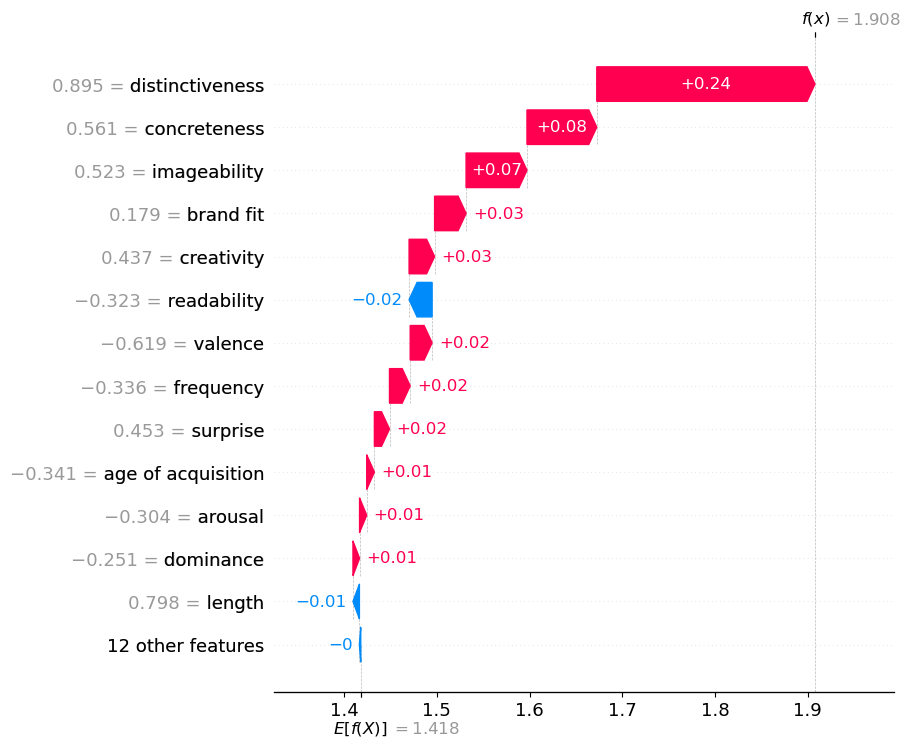

In [ ]:
_train_25 = pd.read_csv("./dataset/level1_mean_z.csv")

with open("./models/trained_model_summary25_binomial_recognition.pkl", "rb") as f:
    _model_r25 = pickle.load(f)["model"]

_cols_r25 = [c for c in predictor_cols_25 if c in _model_r25.params.index]
_coef_r25 = np.array([_model_r25.params[c] for c in _cols_r25])
_intercept_r25 = _model_r25.params.get("Intercept", _model_r25.params.get("const", 0.0))

_explainer_r25 = shap.LinearExplainer((_coef_r25, _intercept_r25), _train_25[_cols_r25].values)

# --- SHAP importance values table ---
_sv_train_r25 = _explainer_r25(_train_25[_cols_r25])
_mean_abs_r25 = np.mean(np.abs(_sv_train_r25.values), axis=0)
_total_r25 = _mean_abs_r25.sum()
shap_importance_recognition = pd.DataFrame({
    "Feature": _cols_r25,
    "Mean |SHAP|": np.round(_mean_abs_r25, 6),
    "% Importance": np.round(_mean_abs_r25 / _total_r25 * 100, 2)
}).sort_values("% Importance", ascending=False).reset_index(drop=True)
print("SHAP Feature Importance — Recognition (training data)")
display(shap_importance_recognition)

# --- Per-slogan waterfall ---
_sv_recognition = _explainer_r25(pd.DataFrame(_df_features_recognition_25[_cols_r25].values, columns=_cols_r25))
sample_ind = 0  # index of target slogan in example_slogans.csv change to show SHAP waterfall plot for a different slogan
print(f"Slogan: {results_recognition_25.iloc[sample_ind]['slogan']}")
print(f"Predicted recognition: {results_recognition_25.iloc[sample_ind]['predicted_recognition']:.3f}")
shap.plots.waterfall(_sv_recognition[sample_ind], max_display=14)


### 4e. Recall Proxy Factors Model (Summary Features) <a id='proxy-recall-25'></a>

This model predicts recall using the 25 aggregated summary features proxied from embeddings.

In [ ]:
def predict_recall_summary25(
    csv_path,
    recall_model_path='./models/trained_model_summary25_binomial_recall.pkl',
    proxy_models_path='./models/proxy_models.pkl',
    training_statistics_path='./models/training_statistics.pkl',
    slogan_column='slogan',
    brand_column='brand',
    api_key=None,
    return_features=False
):
    """
    Predict recall using the Binomial 25 Summary Factors model.
    Pipeline: slogan+brand -> embeddings -> proxy 45 raw features -> aggregate to 25 -> predict.
    """
    slogan_df = pd.read_csv(csv_path)
    df_proxied, _models_dict = apply_proxied_features(
        slogan_df, proxy_models_path, slogan_column, brand_column, api_key=api_key
    )
    df_proxied_z = zscore_proxied_features_deployment(
        df_proxied, proxy_models_path=proxy_models_path, training_stats_path=training_statistics_path
    )
    df_25 = aggregate_to_25(df_proxied_z, small_theories_25)
    import statsmodels.api as sm_
    X = sm_.add_constant(df_25[predictor_cols_25], has_constant='add')
    with open(recall_model_path, 'rb') as f_:
        model = pickle.load(f_)['model']
    preds = model.predict(X)
    results = slogan_df[[slogan_column]].copy()
    if brand_column in slogan_df.columns:
        results[brand_column] = slogan_df[brand_column]
    results['predicted_recall'] = preds.values
    if return_features:
        return results, df_25
    return results

#### Example Usage

In [ ]:
# Example: Predict recall using proxy features model (25 feature summary)
# Requires: CSV with 'slogan' and 'brand' columns

results_recall_25, _df_features_recall_25 = predict_recall_summary25(
    csv_path='example_slogans.csv',
    api_key=api_key,
    return_features=True
)
print('Recall predictions (25 feature summary):')
display(results_recall_25)

Loading proxy models from ./models/proxy_models.pkl...
Computing slogan embeddings for 2 rows...


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Computing brand embeddings for 2 rows...
Applying proxy models to generate features...
Loading training statistics from ./models/training_statistics.pkl...
Z-scoring continuous features...
Recall predictions (25 feature summary):


Trying to unpickle estimator Ridge from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator LogisticRegression from version 1.5.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


,slogan,brand,predicted_recall
0,Equipment that doesn’t care about the weather,Orvix,0.105098
1,"Strength you can hear, feel, and trust",Kavelo,0.038787


SHAP values and diagnostics: SHAP importance values and SHAP waterfall plot for a specified slogan that is being tested.

The SHAP waterfall plot x-axis uses log-odds. So, for example, an expectation in log-odds of -2.547 corresponds to an average recall percentage of 9%.

To change the tested slogan for which the waterfall plot is shown, change sample_ind below.


SHAP Feature Importance — Recall (training data)


,Feature,Mean |SHAP|,% Importance
0,brand fit,0.387087,19.17
1,creativity,0.247052,12.24
2,closest brand similarity,0.174117,8.62
3,metaphor,0.147239,7.29
4,readability,0.140303,6.95
5,imageability,0.104600,5.18
6,valence,0.103588,5.13
7,orthographic,0.100832,4.99
8,liking,0.095734,4.74
9,humor,0.064747,3.21


Slogan: Equipment that doesn’t care about the weather
Predicted recall: 0.105


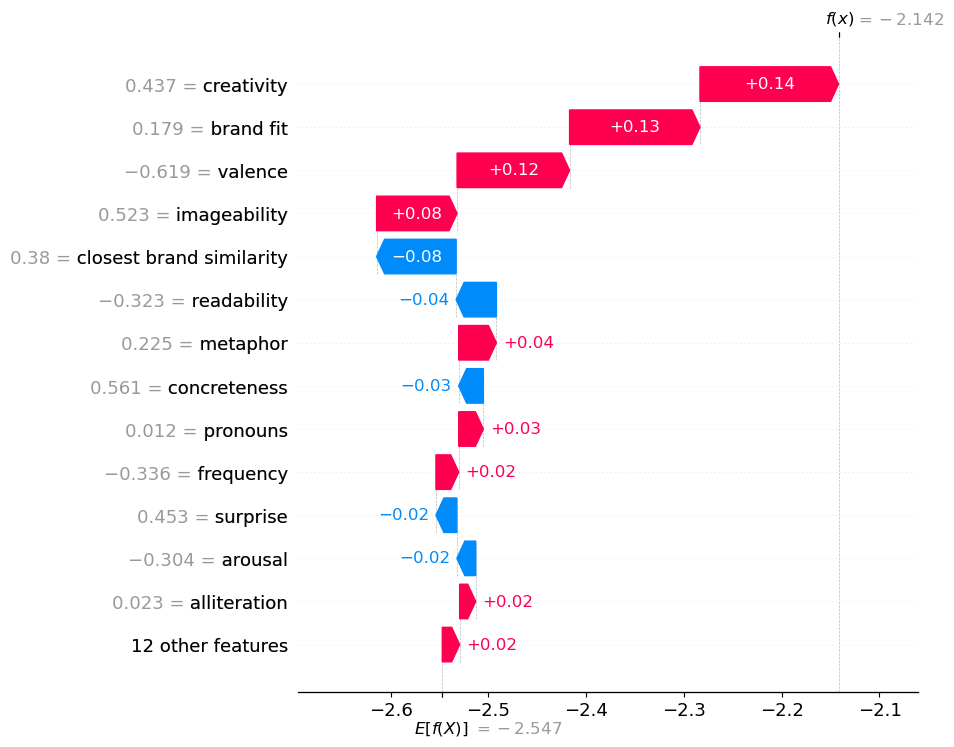

In [ ]:
# SHAP Feature Importance + Per-Slogan SHAP Waterfall

with open("./models/trained_model_summary25_binomial_recall.pkl", "rb") as f:
    _model_c25 = pickle.load(f)["model"]

_cols_c25 = [c for c in predictor_cols_25 if c in _model_c25.params.index]
_coef_c25 = np.array([_model_c25.params[c] for c in _cols_c25])
_intercept_c25 = _model_c25.params.get("Intercept", _model_c25.params.get("const", 0.0))

_explainer_c25 = shap.LinearExplainer((_coef_c25, _intercept_c25), _train_25[_cols_c25].values)

# --- SHAP importance values table ---
_sv_train_c25 = _explainer_c25(_train_25[_cols_c25])
_mean_abs_c25 = np.mean(np.abs(_sv_train_c25.values), axis=0)
_total_c25 = _mean_abs_c25.sum()
shap_importance_recall = pd.DataFrame({
    "Feature": _cols_c25,
    "Mean |SHAP|": np.round(_mean_abs_c25, 6),
    "% Importance": np.round(_mean_abs_c25 / _total_c25 * 100, 2)
}).sort_values("% Importance", ascending=False).reset_index(drop=True)
print("SHAP Feature Importance — Recall (training data)")
display(shap_importance_recall)

# --- Per-slogan waterfall ---
_sv_recall = _explainer_c25(pd.DataFrame(_df_features_recall_25[_cols_c25].values, columns=_cols_c25))
sample_ind = 0  # index of target slogan in example_slogans.csv change to show SHAP waterfall plot for a different slogan
print(f"Slogan: {results_recall_25.iloc[sample_ind]['slogan']}")
print(f"Predicted recall: {results_recall_25.iloc[sample_ind]['predicted_recall']:.3f}")
shap.plots.waterfall(_sv_recall[sample_ind], max_display=14)
